In [1]:
# 訓練データとテストデータの画像を読み込む
# （サイズは縦横224pxにリサイズする）
import tensorflow as tf

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "dog_cat_photos/train",
    image_size=(224, 224),
    label_mode="binary",
    batch_size=32,
    shuffle=True
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "dog_cat_photos/test",
    image_size=(224, 224),
    label_mode="binary",
    batch_size=32,
    shuffle=False
)

Found 300 files belonging to 2 classes.
Found 100 files belonging to 2 classes.


In [2]:
# データの詳細を表示する
list(train_dataset.as_numpy_iterator())[0]

(array([[[[6.20000000e+01, 7.30000000e+01, 7.90000000e+01],
          [6.20111618e+01, 7.30066986e+01, 7.90089264e+01],
          [6.36852684e+01, 7.40111618e+01, 8.03482132e+01],
          ...,
          [1.87662949e+02, 1.96662949e+02, 2.03662949e+02],
          [1.87997772e+02, 1.96997772e+02, 2.03997772e+02],
          [1.88000000e+02, 1.97000000e+02, 2.04000000e+02]],
 
         [[6.19955368e+01, 7.29910736e+01, 7.89933014e+01],
          [6.20066910e+01, 7.29977722e+01, 7.90022278e+01],
          [6.36800499e+01, 7.40029831e+01, 8.03415146e+01],
          ...,
          [1.87669647e+02, 1.96665176e+02, 2.03667419e+02],
          [1.88004471e+02, 1.97000000e+02, 2.04002243e+02],
          [1.88006699e+02, 1.97002228e+02, 2.04004471e+02]],
 
         [[6.13258934e+01, 7.16517868e+01, 7.79888382e+01],
          [6.13363037e+01, 7.16592331e+01, 7.79977646e+01],
          [6.28975563e+01, 7.27765503e+01, 7.93370514e+01],
          ...,
          [1.88674103e+02, 1.97000000e+02, 2.0433

In [3]:
# 分類名（dog／cat）をリストとして格納する
class_names = train_dataset.class_names
class_names

['cat', 'dog']

In [4]:
# 画像の水増しをする関数の定義
def flip_left_right(image, label):   # 左右反転
    image = tf.image.flip_left_right(image)
    return image, label

def flip_up_down(image, label):      # 上下反転
    image = tf.image.flip_up_down(image)
    return image, label

def rot90(image, label):             # 反時計回りに90度回転
    image = tf.image.rot90(image)
    return image, label

def rot180(image, label):            # 反時計回りに180度回転
    image = tf.image.rot90(image, k=2)
    return image, label

def rot270(image, label):            # 反時計回りに270度回転
    image = tf.image.rot90(image, k=3)
    return image, label

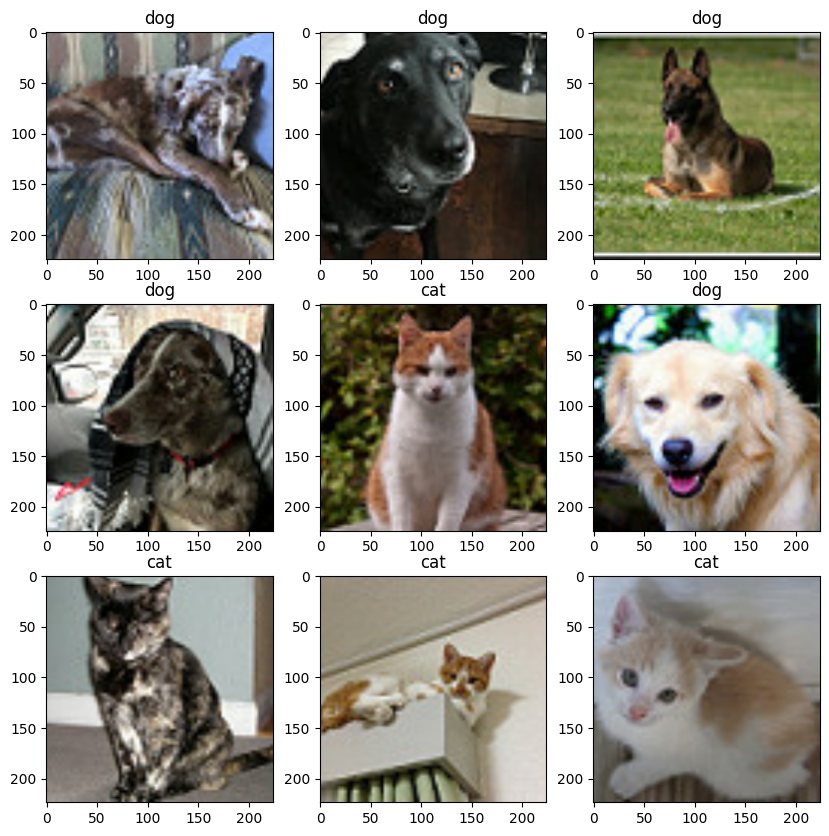

In [5]:
# 訓練データの一部を表示して確認
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

In [6]:
# MobileNetV2モデルを作成する
input_layer = tf.keras.Input(shape=(224, 224, 3))   # 入力層
l_layer = tf.keras.applications.mobilenet_v2.preprocess_input(input_layer)   # 前処理（正規化）をする層

base_model = tf.keras.applications.mobilenet_v2.MobileNetV2(
    input_shape=(224, 224, 3),
    input_tensor=l_layer,
    include_top=False,
    weights="imagenet",
    pooling='avg'
)
base_model.trainable = False

In [7]:
# Dense層を追加する
output_layer = tf.keras.layers.Dense(1, activation='sigmoid')

# base_modelに先ほどのDense層を追加したモデルを作成する
model = tf.keras.Sequential([
    base_model,
    output_layer
])

# modelをcompileする
model.compile(optimizer="adam",
              loss='binary_crossentropy',
              metrics=["accuracy"])

# modelに学習させる
model.fit(train_dataset, epochs=20)

# テストデータで分類を実行する
pred_data = model.predict(test_dataset)

# 分類した結果を確認する
pred_data

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 240ms/step - accuracy: 0.7033 - loss: 0.5805
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 235ms/step - accuracy: 0.9500 - loss: 0.2707
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 239ms/step - accuracy: 0.9767 - loss: 0.1559
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 236ms/step - accuracy: 0.9833 - loss: 0.1091
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 232ms/step - accuracy: 0.9867 - loss: 0.0872
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 235ms/step - accuracy: 0.9867 - loss: 0.0716
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 232ms/step - accuracy: 0.9900 - loss: 0.0627
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 232ms/step - accuracy: 0.9900 - loss: 0.0558
Epoch 9/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 234ms/step - accuracy: 0.9967 - loss: 0.0499
Epoch 10/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 233ms/step - accuracy: 0.9967 - loss: 0.0454
Epoch 11/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 234ms/step - accuracy: 0.9967 - loss: 0.0411
Epoch 12/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 237ms/step

array([[3.60238762e-03],
       [1.18449647e-02],
       [3.80363059e-03],
       [2.01204885e-03],
       [8.32616759e-04],
       [8.36244843e-04],
       [1.20071217e-03],
       [5.88873925e-04],
       [7.10041204e-04],
       [8.69678857e-04],
       [8.43811373e-04],
       [4.24446585e-03],
       [1.50483276e-03],
       [2.15281779e-03],
       [2.12296465e-04],
       [9.93278954e-05],
       [5.03882824e-04],
       [1.37009309e-03],
       [1.02448009e-03],
       [4.19801585e-02],
       [1.01741016e-01],
       [1.32881939e-01],
       [1.03939539e-02],
       [3.36488802e-03],
       [4.52612281e-01],
       [1.97221749e-02],
       [1.98051129e-02],
       [2.83171912e-03],
       [3.39317694e-02],
       [8.07186589e-04],
       [2.61467905e-03],
       [3.18739355e-01],
       [1.07300410e-03],
       [1.67318655e-03],
       [1.27289612e-02],
       [9.78192389e-01],
       [5.15613332e-02],
       [7.44941644e-03],
       [1.19859977e-02],
       [7.55830668e-03],


In [ ]:
# evaluate()でモデルの性能を評価する 
model.evaluate(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 178ms/step - accuracy: 0.9900 - loss: 0.0610


[0.06097101792693138, 0.9900000095367432]